# Pobreza multidimensional en Colombia: factores asociados según la ECV 2023
**APES – Primera entrega** · Jeisson Sánchez y Juan Bogotá

Fuente: Encuesta Nacional de Calidad de Vida (ECV) 2023, DANE. Unidad de análisis: hogar y persona (llave `DIRECTORIO` + `SECUENCIA_P` [+ `ORDEN`]).

## 0. SETUP

In [1]:
# SETUP
# Qué hace: instala dependencias, importa las librerías, fija opciones de visualización y define las rutas del proyecto.
# Por qué: todas las rutas son relativas a la raíz del repo, así el notebook corre igual en el computador de cualquiera de los dos.
%pip install -q openpyxl pyarrow

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Opciones de presentación: sin advertencias, hasta 100 columnas y 2 decimales con separador de miles.
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", context="notebook")
# Semilla fija por reproducibilidad.
np.random.seed(42)

# Ruta base: raíz del repo (el notebook vive en notebooks/)
# El notebook vive en notebooks/, así que la raíz del repo es la carpeta superior (..).
BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Carpetas del proyecto: CSV originales (data/raw/csv), bases limpias (data/processed) y gráficos (figures).
RAW_CSV   = os.path.join(BASE_PATH, "data", "raw", "csv")
PROCESSED = os.path.join(BASE_PATH, "data", "processed")
FIGURES   = os.path.join(BASE_PATH, "figures")
# Crea las carpetas de salida si no existen.
os.makedirs(PROCESSED, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

# Verificación: debe mostrar la raíz del repo y los 11 CSV de la ECV.
print("BASE_PATH:", BASE_PATH)
print("CSV encontrados:", sorted(os.listdir(RAW_CSV)))

Note: you may need to restart the kernel to use updated packages.
BASE_PATH: c:\Users\Jeisson\OneDrive\Escritorio\APES_M\Proyecto
CSV encontrados: ['condiciones.csv', 'data-raw-csv.zip', 'diseno_muestra.csv', 'educacion.csv', 'fuerza_trabajo.csv', 'personas.csv', 'primera_infancia.csv', 'salud.csv', 'servicios.csv', 'tic.csv', 'trabajo_infantil.csv', 'vivienda.csv']


## 1. CARGA DE DATOS

In [2]:
# CARGA DE LOS 11 MÓDULOS DE LA ECV
# Qué hace: lee cada CSV del DANE en un DataFrame y los guarda en el diccionario dfs.
# Por qué: cada tema (personas, vivienda, salud...) viene en un archivo distinto y después se unen por llave.
# Nombre corto de cada módulo -> archivo CSV en data/raw/csv.
ARCHIVOS = {
    "personas":        "personas.csv",
    "vivienda":        "vivienda.csv",
    "servicios":       "servicios.csv",
    "condiciones":     "condiciones.csv",
    "educacion":       "educacion.csv",
    "fuerza_trabajo":  "fuerza_trabajo.csv",
    "salud":           "salud.csv",
    "diseno_muestra":  "diseno_muestra.csv",
    "trabajo_infantil":"trabajo_infantil.csv",
    "primera_infancia":"primera_infancia.csv",
    "tic":             "tic.csv",
}

# Función auxiliar: detecta el separador (coma o punto y coma) y la codificación (utf-8 o latin-1) mirando la primera línea.
def leer_csv(ruta):
    """Lee un CSV del DANE probando separador y codificación."""
    with open(ruta, "rb") as f:
        primera = f.readline()
    for enc in ("utf-8", "latin-1"):
        try:
            linea = primera.decode(enc)
            break
        except UnicodeDecodeError:
            continue
    sep = ";" if linea.count(";") > linea.count(",") else ","
    return pd.read_csv(ruta, sep=sep, encoding=enc, low_memory=False)

# Carga los 11 archivos y estandariza los nombres de columna (sin espacios y en mayúsculas).
dfs = {}
for nombre, archivo in ARCHIVOS.items():
    dfs[nombre] = leer_csv(os.path.join(RAW_CSV, archivo))
    dfs[nombre].columns = dfs[nombre].columns.str.strip().str.upper()

# Resumen de dimensiones
# Tabla de control: filas y columnas de cada módulo.
resumen = pd.DataFrame({
    "filas":    {k: v.shape[0] for k, v in dfs.items()},
    "columnas": {k: v.shape[1] for k, v in dfs.items()},
})
resumen

,filas,columnas
personas,240212,79
vivienda,86063,47
servicios,86405,96
condiciones,86405,125
educacion,223695,84
fuerza_trabajo,196657,97
salud,240212,153
diseno_muestra,240212,11
trabajo_infantil,27038,13
primera_infancia,16517,63


In [3]:
# VERIFICACIÓN DE LLAVES Y TAMAÑOS
# Qué hace: comprueba que todos los módulos tengan las columnas llave y que el número de hogares y personas coincida con la ficha técnica.
# Llaves: hogar = DIRECTORIO + SECUENCIA_P; persona = hogar + ORDEN.
# Definición de las llaves de unión (se usan en todo el notebook).
LLAVE_HOGAR = ["DIRECTORIO", "SECUENCIA_P"]
LLAVE_PERSONA = LLAVE_HOGAR + ["ORDEN"]

# ¿Cada módulo trae las columnas de la llave de hogar y de la llave de persona?
for nombre, df in dfs.items():
    tiene_hogar   = all(c in df.columns for c in LLAVE_HOGAR)
    tiene_persona = all(c in df.columns for c in LLAVE_PERSONA)
    print(f"{nombre:18s} llave hogar: {tiene_hogar!s:5} | llave persona: {tiene_persona!s:5}")

# Conteos esperados según la ficha técnica: 86.405 hogares y 240.212 personas.
n_hogares  = dfs["personas"][LLAVE_HOGAR].drop_duplicates().shape[0]
n_personas = dfs["personas"].shape[0]
print(f"\nHogares en 'personas':  {n_hogares:,}  (esperado 86.405)")
print(f"Personas en 'personas': {n_personas:,}  (esperado 240.212)")

personas           llave hogar: True  | llave persona: True 
vivienda           llave hogar: True  | llave persona: True 
servicios          llave hogar: True  | llave persona: True 
condiciones        llave hogar: True  | llave persona: True 
educacion          llave hogar: True  | llave persona: True 
fuerza_trabajo     llave hogar: True  | llave persona: True 
salud              llave hogar: True  | llave persona: True 
diseno_muestra     llave hogar: True  | llave persona: True 
trabajo_infantil   llave hogar: True  | llave persona: True 
primera_infancia   llave hogar: True  | llave persona: True 
tic                llave hogar: True  | llave persona: True 

Hogares en 'personas':  86,405  (esperado 86.405)
Personas en 'personas': 240,212  (esperado 240.212)


In [4]:
# VISTA RÁPIDA
# Qué hace: muestra las primeras 3 filas (10 primeras columnas) de cada módulo para reconocer su estructura.
for nombre, df in dfs.items():
    print(f"\n=== {nombre} {df.shape} ===")
    display(df.head(3).iloc[:, :10])


=== personas (240212, 79) ===


,DIRECTORIO,SECUENCIA_ENCUESTA,SECUENCIA_P,ORDEN,FEX_C,P6016,P1894,P6020,P6034,P6040
0,7910114,1,1,1,282.37,1,3,2,1,43
1,7910114,2,1,2,282.37,2,2,2,1,16
2,7910115,1,1,1,3.05,1,3,1,1,54



=== vivienda (86063, 47) ===


,DIRECTORIO,SECUENCIA_ENCUESTA,SECUENCIA_P,ORDEN,P1_DEPARTAMENTO,P1_MUNICIPIO,REGION,FEX_C,CANT_HOG_COMPLETOS,CANT_HOGARES_VIVIENDA
0,7910114,1,1,1,73,1,3,282.37,1,1
1,7910115,1,1,1,97,1,9,3.05,1,1
2,7910119,1,1,1,66,440,3,31.29,1,1



=== servicios (86405, 96) ===


...

,DIRECTORIO,SECUENCIA_ENCUESTA,SECUENCIA_P,ORDEN,FEX_C,P10000,P400,P401,P402,P403
0,7910127,3,1,3,120.32,3,3,2.00,2.00,2.00
1,7910131,3,1,3,108.94,3,3,2.00,2.00,2.00
2,7910137,3,1,3,256.47,1,3,2.00,2.00,2.00



=== primera_infancia (16517, 63) ===


,DIRECTORIO,SECUENCIA_ENCUESTA,SECUENCIA_P,ORDEN,FEX_C,P51,P772,P773,P6169,P6169S1
0,7910115,5,1,5,3.05,6,5.00,NaN,NaN,NaN
1,7910127,4,1,4,120.32,2,4.00,NaN,NaN,NaN
2,7910131,4,1,4,108.94,2,6.00,NaN,NaN,NaN



=== tic (223695, 86) ===


,DIRECTORIO,SECUENCIA_ENCUESTA,SECUENCIA_P,ORDEN,FEX_C,P1910,P1911,P1912,P1084,P1710
0,7910114,1,1,1,282.37,5,5,5,1,NaN
1,7910114,2,1,2,282.37,2,5,5,1,NaN
2,7910115,1,1,1,3.05,5,5,5,5,NaN


**Conclusión.** Los 11 módulos cargan y las llaves están en todos. `personas` tiene 86.405 hogares y 240.212 personas, igual que la ficha técnica.

## 2. INTEGRACIÓN
### 2.1 Duplicados por llave en cada módulo

In [5]:
# 2.1 DUPLICADOS POR LLAVE
# Qué hace: para cada módulo cuenta las filas repetidas según la llave de hogar y la de persona.
# Cómo leerlo: dup_llave_persona = 0 significa que la llave de persona identifica una fila única.
# dup_llave_hogar > 0 es normal en módulos de personas (varias personas por hogar) pero no en módulos de hogar.
filas = []
for nombre, df in dfs.items():
    filas.append({
        "modulo": nombre,
        "filas": len(df),
        "dup_llave_hogar": df.duplicated(LLAVE_HOGAR).sum(),
        "dup_llave_persona": df.duplicated(LLAVE_PERSONA).sum(),
        "ORDEN_unicos": df["ORDEN"].nunique(),
    })
pd.DataFrame(filas).set_index("modulo")

,filas,dup_llave_hogar,dup_llave_persona,ORDEN_unicos
modulo,,,,
personas,240212,153807,0,24
vivienda,86063,0,0,1
servicios,86405,342,0,6
condiciones,86405,342,0,6
educacion,223695,137290,0,21
fuerza_trabajo,196657,110252,0,19
salud,240212,153807,0,24
diseno_muestra,240212,153807,0,24
trabajo_infantil,27038,5612,0,15


**Conclusión.** En ningún módulo se repite la llave de persona (`DIRECTORIO` + `SECUENCIA_P` + `ORDEN`). `servicios` y `condiciones` tienen 342 llaves de hogar repetidas y `vivienda` tiene una fila por vivienda (86.063), así que en esos módulos la llave de hogar no es la misma que en `personas`.

### 2.2 ¿Cuántos hogares de 'personas' no aparecen en cada módulo de hogar?

In [6]:
# 2.2 HOGARES SIN REGISTRO EN LOS MÓDULOS DE HOGAR
# Qué hace: cruza la lista de hogares (tomada de 'personas') con vivienda, servicios y condiciones usando DIRECTORIO + SECUENCIA_P.
# Resultado: 342 hogares no aparecen, es decir, la llave de esos módulos no coincide con la de personas.
# Lista única de hogares (86.405) tomada del módulo de personas.
hogares = dfs["personas"][LLAVE_HOGAR].drop_duplicates()
# merge con indicator=True: '_merge == left_only' marca los hogares que no encuentran pareja en el módulo.
for m in ["vivienda", "servicios", "condiciones"]:
    cruce = hogares.merge(dfs[m][LLAVE_HOGAR].drop_duplicates(), on=LLAVE_HOGAR, how="left", indicator=True)
    print(f"{m:12s} hogares sin registro: {(cruce['_merge'] == 'left_only').sum():,}")

# Alternativa: ¿vivienda se une solo por DIRECTORIO?
sin_dir = hogares[~hogares["DIRECTORIO"].isin(dfs["vivienda"]["DIRECTORIO"])]
print(f"\nHogares cuyo DIRECTORIO no está en vivienda: {len(sin_dir):,}")

vivienda     hogares sin registro: 342
servicios    hogares sin registro: 342
condiciones  hogares sin registro: 342

Hogares cuyo DIRECTORIO no está en vivienda: 0


**Conclusión.** Con `DIRECTORIO` + `SECUENCIA_P`, 342 hogares quedan sin registro en `vivienda`, `servicios` y `condiciones`. Todos los `DIRECTORIO` sí están en `vivienda`, por lo que `vivienda` se une solo por `DIRECTORIO`.

### 2.3 Buscar variables clave en todos los módulos

In [7]:
# 2.3 BÚSQUEDA DE VARIABLES CLAVE
# Qué hace: busca por texto en los nombres de columna de todos los módulos (IPM, pobreza, ingreso, factor de expansión, zona, región...).
# Resultado: el IPM NO viene calculado (hay que construirlo); el ingreso está en servicios; FEX_C está en todos los módulos.
palabras = ["IPM", "POBREZ", "INGRES", "I_HOGAR", "PERCAPITA", "FEX", "FACTOR",
            "CLASE", "REGION", "DOMINIO", "DEPARTAMENTO", "P6040", "P6020", "P6050", "P6008"]

for p in palabras:
    hallazgos = {m: [c for c in df.columns if p in c] for m, df in dfs.items()}
    hallazgos = {m: c for m, c in hallazgos.items() if c}
    print(f"\n[{p}]")
    for m, cols in hallazgos.items():
        print(f"   {m}: {cols[:8]}")


[IPM]

[POBREZ]

[INGRES]

[I_HOGAR]
   servicios: ['I_HOGAR']

[PERCAPITA]
   servicios: ['PERCAPITA']

[FEX]
   personas: ['FEX_C']
   vivienda: ['FEX_C']
   servicios: ['FEX_C']
   condiciones: ['FEX_C']
   educacion: ['FEX_C']
   fuerza_trabajo: ['FEX_C']
   salud: ['FEX_C']
   diseno_muestra: ['FEX_C']
   trabajo_infantil: ['FEX_C']
   primera_infancia: ['FEX_C']
   tic: ['FEX_C']

[FACTOR]

[CLASE]
   vivienda: ['CLASE']

[REGION]
   vivienda: ['REGION']

[DOMINIO]

[DEPARTAMENTO]
   vivienda: ['P1_DEPARTAMENTO']

[P6040]
   personas: ['P6040']

[P6020]
   personas: ['P6020']

[P6050]

[P6008]


**Conclusión.** El microdato no trae el IPM ni una variable de pobreza: hay que **construirlo** (Sección 4). El ingreso (`I_HOGAR`, `PERCAPITA`) está en `servicios`; el factor de expansión `FEX_C` está en todos los módulos; `CLASE`, `REGION` y `P1_DEPARTAMENTO` están en `vivienda`; edad (`P6040`) y sexo (`P6020`) están en `personas`.

### 2.4 Bases integradas (personas y hogares)

In [8]:
# 2.4 INTEGRACIÓN: BASE DE PERSONAS Y BASE DE HOGARES
# Qué hace: une los módulos en dos bases: df_personas (una fila por persona) y df_hogares (una fila por hogar).
# Por qué: las variables del IPM están repartidas en varios módulos.
# Función de unión: left merge que agrega solo las columnas que la base aún no tiene (evita columnas duplicadas).
def unir(base, df, llave, how="left"):
    """Une df a base, agregando solo columnas que base aún no tiene."""
    nuevas = [c for c in df.columns if c not in base.columns or c in llave]
    return base.merge(df[nuevas].drop_duplicates(llave), on=llave, how=how)



# --- Base de personas: parte de 'personas' y le agrega salud, diseño muestral, educación, trabajo, TIC,
# trabajo infantil y primera infancia, todos con la llave de persona.
df_personas = dfs["personas"].copy()
for m in ["salud", "diseno_muestra", "educacion", "fuerza_trabajo", "tic",
          "trabajo_infantil", "primera_infancia"]:
    df_personas = unir(df_personas, dfs[m], LLAVE_PERSONA)
# Control: un left merge no debe perder ni duplicar personas.
assert len(df_personas) == 240212, "Se perdieron o duplicaron personas"


# --- Base de hogares. En servicios, condiciones y vivienda SECUENCIA_P vale siempre 1 y ORDEN es el número de hogar;
# por eso se renombra ORDEN como SECUENCIA_P para poder unir con la llave de hogar (ver 2.5).
def a_llave_hogar(df):
    return df.drop(columns=["SECUENCIA_P"]).rename(columns={"ORDEN": "SECUENCIA_P"})

# Se parte de los 86.405 hogares y se agregan servicios (incluye el ingreso) y condiciones.
df_hogares = hogares.copy()
df_hogares = unir(df_hogares, a_llave_hogar(dfs["servicios"]), LLAVE_HOGAR)
df_hogares = unir(df_hogares, a_llave_hogar(dfs["condiciones"]), LLAVE_HOGAR)

# vivienda: una fila por vivienda, se une solo por DIRECTORIO
viv = dfs["vivienda"].drop(columns=["SECUENCIA_P", "ORDEN"], errors="ignore")
df_hogares = unir(df_hogares, viv, ["DIRECTORIO"])

# Tamaño del hogar
# Tamaño del hogar = número de personas por hogar, contado desde la base de personas.
tam = df_personas.groupby(LLAVE_HOGAR).size().rename("TAM_HOGAR").reset_index()
df_hogares = df_hogares.merge(tam, on=LLAVE_HOGAR, how="left")
# Control: deben quedar exactamente 86.405 hogares.
assert len(df_hogares) == 86405, "Se perdieron o duplicaron hogares"

# Verificaciones: dimensiones finales, nulos en variables clave y coherencia del tamaño del hogar con CANT_PERSONAS_HOGAR.
print("df_personas:", df_personas.shape)
print("df_hogares: ", df_hogares.shape)
for c in ["I_HOGAR", "PERCAPITA", "CLASE", "TAM_HOGAR"]:
    print(f"{c} nulo:", df_hogares[c].isna().sum())
print("TAM_HOGAR != CANT_PERSONAS_HOGAR:",
      (df_hogares["TAM_HOGAR"] != df_hogares["CANT_PERSONAS_HOGAR"]).sum())

df_personas: (240212, 552)
df_hogares:  (86405, 258)
I_HOGAR nulo: 0
PERCAPITA nulo: 0
CLASE nulo: 0
TAM_HOGAR nulo: 0
TAM_HOGAR != CANT_PERSONAS_HOGAR: 0


**Conclusión.** `df_personas` queda con 240.212 filas y `df_hogares` con 86.405. `I_HOGAR`, `PERCAPITA`, `CLASE` y `TAM_HOGAR` no tienen nulos, y el tamaño calculado coincide con `CANT_PERSONAS_HOGAR`. Se conservan todas las columnas por ahora; en la Sección 4.2 se guardan solo las que se usan.

### 2.5 Llave de hogar en servicios y condiciones

In [9]:
# 2.5 CONFIRMAR LA LLAVE DE HOGAR EN SERVICIOS Y CONDICIONES
# Qué hace: prueba la hipótesis de que en esos módulos el hogar se identifica con DIRECTORIO + ORDEN.
# Resultado: con esa llave quedan 0 hogares sin registro, así que la hipótesis se confirma.
cols_id = lambda df: [c for c in df.columns if "SECUENCIA" in c or c in ("DIRECTORIO", "ORDEN")]
print("servicios:", cols_id(dfs["servicios"]))
print("personas: ", cols_id(dfs["personas"]))
print("personas SECUENCIA_P:", sorted(dfs["personas"]["SECUENCIA_P"].unique())[:10])
print("servicios SECUENCIA_P:", sorted(dfs["servicios"]["SECUENCIA_P"].unique())[:10])
print("servicios ORDEN:", sorted(dfs["servicios"]["ORDEN"].unique()))

# Hipótesis: en servicios/condiciones el hogar es DIRECTORIO + ORDEN
for m in ["servicios", "condiciones"]:
    der = dfs[m][["DIRECTORIO", "ORDEN"]].rename(columns={"ORDEN": "SECUENCIA_P"})
    c = hogares.merge(der, on=LLAVE_HOGAR, how="left", indicator=True)
    print(f"{m}: hogares sin registro con DIRECTORIO+ORDEN = {(c['_merge'] == 'left_only').sum():,}")

# Verificación contra la "Estructura de base de datos ECV 2023" (DANE):
# en las tablas de hogar y de personas, ORDEN debe coincidir con SECUENCIA_ENCUESTA.
for m in ["servicios", "condiciones", "personas", "salud", "educacion"]:
    d = dfs[m]
    print(f"{m:12s} ORDEN == SECUENCIA_ENCUESTA en {100 * (d['ORDEN'] == d['SECUENCIA_ENCUESTA']).mean():.2f}% de las filas")

servicios: ['DIRECTORIO', 'SECUENCIA_ENCUESTA', 'SECUENCIA_P', 'ORDEN']
personas:  ['DIRECTORIO', 'SECUENCIA_ENCUESTA', 'SECUENCIA_P', 'ORDEN']
personas SECUENCIA_P: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
servicios SECUENCIA_P: [np.int64(1)]
servicios ORDEN: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
servicios: hogares sin registro con DIRECTORIO+ORDEN = 0
condiciones: hogares sin registro con DIRECTORIO+ORDEN = 0
servicios    ORDEN == SECUENCIA_ENCUESTA en 100.00% de las filas
condiciones  ORDEN == SECUENCIA_ENCUESTA en 100.00% de las filas
personas     ORDEN == SECUENCIA_ENCUESTA en 100.00% de las filas
salud        ORDEN == SECUENCIA_ENCUESTA en 100.00% de las filas
educacion    ORDEN == SECUENCIA_ENCUESTA en 100.00% de las filas


**Conclusión.** Según la *Estructura de base de datos ECV 2023* del DANE, en las tablas de hogar `SECUENCIA_ENCUESTA` identifica el hogar dentro de la vivienda y `SECUENCIA_P` vale siempre 1; en las tablas de personas, `SECUENCIA_P` identifica el hogar. En los datos, `ORDEN` coincide con `SECUENCIA_ENCUESTA` en el 100% de las filas, así que unir por `DIRECTORIO` + `ORDEN` equivale a la llave oficial. Con ella los 342 hogares faltantes aparecen (0 sin registro), y por eso esos módulos se unen con `a_llave_hogar()`. `vivienda` se une solo por `DIRECTORIO`.

### 2.6 Parentesco, tamaño del hogar y estrato

In [10]:
# 2.6 PARENTESCO, TAMAÑO DEL HOGAR, ESTRATO Y DICCIONARIO
# Qué hace: (1) busca columnas por nombre, (2) carga el diccionario de datos del DANE y define dos funciones de consulta: buscar_dic() y ver().
# Resultado: P6051 es el parentesco (1 = jefe/a); ESTRATO2020 es de diseño muestral, no el estrato socioeconómico.
for pal in ["PARENT", "JEFE", "P6051", "CANT", "PERSONAS", "ESTRATO", "ZONA", "AREA"]:
    print(f"\n[{pal}]")
    for m, df in dfs.items():
        cols = [c for c in df.columns if pal in c]
        if cols:
            print(f"   {m}: {cols[:8]}")

# Diccionario de datos (primera hoja)
# Lee todas las hojas del Excel; la primera tiene el diccionario de variables.
dic = pd.read_excel(os.path.join(BASE_PATH, "data", "docs", "Diccionario de datos_ECV 2023.xlsx"), sheet_name=None)
# Se queda con 4 columnas: módulo, nombre de la variable, texto de la pregunta y categorías de respuesta.
dd = dic[list(dic.keys())[0]].iloc[:, [0, 3, 9, 10]].copy()
dd.columns = ["modulo", "variable", "pregunta", "categorias"]
dd = dd.dropna(subset=["variable"]).reset_index(drop=True)

# buscar_dic('palabra'): lista las variables cuya pregunta o categorías contienen la palabra.
def buscar_dic(palabra, n=10):
    """Busca una palabra en las preguntas y categorías del diccionario."""
    pal = palabra.lower()
    m = (dd["pregunta"].astype(str).str.lower().str.contains(pal, regex=False)
         | dd["categorias"].astype(str).str.lower().str.contains(pal, regex=False))
    print(f"\n[{palabra}]")
    for _, f in dd[m].head(n).iterrows():
        print(f"  {f['variable']:10s} | {str(f['modulo'])[:24]:24s} | {str(f['pregunta'])[:95]}")

# ver('P6051'): imprime la pregunta y los códigos de respuesta de una variable.
def ver(var):
    """Muestra pregunta y categorías de una variable."""
    f = dd[dd["variable"] == var].iloc[0]
    print(f"{var} ({f['modulo']})\n{f['pregunta']}\n{f['categorias']}\n")

# Verificación del jefe de hogar: cada hogar debe tener exactamente un jefe (P6051 == 1).
ver("P6051")
jefes_chk = df_personas[df_personas["P6051"] == 1].groupby(LLAVE_HOGAR).size()
print("Hogares con exactamente 1 jefe:", (jefes_chk == 1).sum(), "de", df_hogares.shape[0])


[PARENT]

[JEFE]

[P6051]
   personas: ['P6051']

[CANT]
   vivienda: ['CANT_HOG_COMPLETOS', 'CANT_HOGARES_VIVIENDA']
   servicios: ['CANT_PERSONAS_HOGAR']

[PERSONAS]
   servicios: ['CANT_PERSONAS_HOGAR']

[ESTRATO]
   diseno_muestra: ['ESTRATO2020']

[ZONA]

[AREA]
P6051 (D. Caracteristicas Y Composición Del Hogar (Para Todas Las Personas Del Hogar))
5. ¿Cuál es el parentesco de ... con el jefe o la jefa de este hogar?
1. Jefe/a del hogar
2. Pareja, esposo/a, cónyuge,  compañero/a
3.  Hijo/a, hijastro/a
4.  Nieto/a
5.  Padre, madre, padrastro, madrastra
6.  Suegro o suegra
7.  Hermano/a, hemanastro/a
8.  Yerno, nuera
9.  Otro/a pariente del/de la jefe/a
10.  Empleado/a del servicio doméstico
11.  Parientes del servicio doméstico
12.  Trabajador/a
13.  Pensionista
14. Otro(a) no pariente

Hogares con exactamente 1 jefe: 86405 de 86405


**Conclusión.** El parentesco es `P6051` (1 = jefe/a del hogar) y el tamaño del hogar también viene en `CANT_PERSONAS_HOGAR`. `ESTRATO2020` es un código de diseño muestral, **no** el estrato socioeconómico; el estrato (1 a 6) es `P8520S1A1` en `vivienda`.

## 3. LIMPIEZA Y VARIABLES DERIVADAS

In [11]:
# 3. LIMPIEZA Y VARIABLES DERIVADAS
# Qué hace: crea las variables que no vienen en los microdatos (años de educación, ocupado, sexo y edad del jefe, estrato válido) y revisa el ingreso.
# 'p' es un alias de df_personas: lo que se agregue aquí queda en df_personas.
p = df_personas

# 3.1 Años de educación aprobados (persona)
# Dos casos según si la persona estudia actualmente:
# - No estudiante: se usa el último nivel (P8587) y el grado aprobado (P8587S1).
# - Estudiante: años aprobados = grado que cursa - 1 (el grado en curso aún no está aprobado).
def anos_no_estudiante(n, g):
    g = g.fillna(0)
    return np.select(
        [n.isin([1, 2]), n == 3, n == 4, n == 5, n >= 6],
        [0, g.clip(0, 5), g.clip(5, 9), g.clip(9, 11), 11 + g],
        default=np.nan)

def anos_estudiante(n, g, sup):
    """Años aprobados = grado que cursa - 1 (metodología DANE)."""
    g = g.fillna(1)
    return np.select(
        [n == 1, n == 2, n == 3, n == 4, n >= 5],
        [0,
         (g - 1).clip(0, 4),
         (np.where(g >= 6, g, 5 + g) - 1).clip(5, 8),
         (np.where(g >= 10, g, 9 + g) - 1).clip(9, 11),
         11 + sup.fillna(0)],
        default=np.nan)

# Estudiante = declara que estudia (P8586 == 1) y reporta el nivel en que está matriculado (P1088).
estudia = (p["P8586"] == 1) & p["P1088"].notna()
# Combina los dos casos en una sola variable ANOS_EDUC.
p["ANOS_EDUC"] = np.where(
    estudia,
    anos_estudiante(p["P1088"], p["P1088S1"], p["P6216"]),
    anos_no_estudiante(p["P8587"], p["P8587S1"]))
p["ANOS_EDUC"] = p["ANOS_EDUC"].clip(upper=22)   # 11 años de básica y media + máximo 11 de superior
# OCUPADO: trabajó la semana pasada, o hizo una actividad paga, o tenía trabajo, o ayudó sin pago en un negocio familiar (P6240, P6250, P6260, P6270).
p["OCUPADO"] = ((p["P6240"] == 1) | (p["P6250"] == 1) | (p["P6260"] == 1) | (p["P6270"] == 1))

# Controles: personas de 15+ sin dato de educación (debe ser 0) y distribución de los años de educación.
m15 = p["P6040"] >= 15
print("Estudiantes con nivel matriculado:", estudia.sum())
print(p[estudia].groupby("P1088")["P1088S1"].agg(["min", "max", "count"]))
print("Personas 15+ sin dato de educación:", p.loc[m15, "ANOS_EDUC"].isna().sum())
print(p.loc[m15, "ANOS_EDUC"].describe())

# 3.2 Jefe de hogar, sexo y edad del jefe
# Se eliminan las columnas si ya existían (permite re-ejecutar la celda sin duplicarlas).
df_hogares = df_hogares.drop(columns=["SEXO_JEFE", "EDAD_JEFE"], errors="ignore")
# Jefe/a del hogar = persona con P6051 == 1; se toma su sexo (P6020) y su edad (P6040).
jefes = (p[p["P6051"] == 1][LLAVE_HOGAR + ["P6020", "P6040"]]
         .drop_duplicates(LLAVE_HOGAR)
         .rename(columns={"P6020": "SEXO_JEFE", "P6040": "EDAD_JEFE"}))
# Se agrega al hogar el sexo y la edad del jefe.
df_hogares = df_hogares.merge(jefes, on=LLAVE_HOGAR, how="left")
print("Hogares sin jefe:", df_hogares["SEXO_JEFE"].isna().sum())

# 3.3 Estrato (vivienda: "Estrato para tarifa"); solo valores 1 a 6 son estratos válidos
# Solo los valores 1 a 6 son estratos válidos; los códigos 0, 8, 9 y los vacíos quedan como nulos.
df_hogares["ESTRATO"] = df_hogares["P8520S1A1"].where(df_hogares["P8520S1A1"].between(1, 6))
print(df_hogares["ESTRATO"].value_counts(dropna=False).sort_index())

# 3.4 Ingreso del hogar
# Revisión del ingreso: distribución y porcentaje de hogares con ingreso 0 (se conservan en la base).
print(df_hogares[["I_HOGAR", "PERCAPITA"]].describe(percentiles=[.01, .25, .5, .75, .99]))
print("Hogares con I_HOGAR == 0:", round((df_hogares["I_HOGAR"] == 0).mean() * 100, 2), "%")

Estudiantes con nivel matriculado: 56033
        min   max  count
P1088                   
1.00   1.00  3.00   4183
2.00   1.00  5.00  21342
3.00   6.00  9.00  16101
4.00  10.00 13.00   6469
5.00   1.00  3.00   1991
6.00   1.00  4.00    819
7.00   1.00  7.00   4732
8.00   1.00  5.00    396
Personas 15+ sin dato de educación: 0
count   184,563.00
mean          8.10
std           4.55
min           0.00
25%           5.00
50%           9.00
75%          11.00
max          22.00
Name: ANOS_EDUC, dtype: float64
Hogares sin jefe: 0
ESTRATO
1.00    41622
2.00    23104
3.00     7442
4.00     2106
5.00      726
6.00      386
NaN     11019
Name: count, dtype: int64
             I_HOGAR      PERCAPITA
count      86,405.00      86,405.00
mean    2,091,450.83     921,965.79
std     3,725,450.91   2,040,082.37
min             0.00           0.00
1%              0.00           0.00
25%       700,000.00     274,750.00
50%     1,300,000.00     505,000.00
75%     2,276,666.67     976,333.33
99%    15,5

**Decisiones de limpieza**
- **Años de educación:** quien estudia cuenta los años hasta el grado anterior al que cursa (metodología DANE); el resto usa el último nivel y grado aprobados. Se recorta en 22 años (11 de básica y media + 11 de superior) porque `P6216` traía valores atípicos hasta 31.
- **Jefe de hogar:** `P6051 == 1`. Todos los hogares tienen jefe.
- **Estrato:** solo se aceptan valores de 1 a 6; los códigos 0, 8 y 9 y los vacíos quedan como nulos (11.019 hogares).
- **Ingreso:** el 1,9% de los hogares reporta ingreso 0 y hay valores extremos (máximo de 250 millones por persona). Se conservan en la base; el univariado excluye los ceros y usa escala logarítmica.
- **Códigos especiales:** en `P6090` (afiliación a salud) el código 9 ("no sabe") se trata como no asegurado, como indica la metodología del IPM.

## 4. VARIABLE OBJETIVO: ÍNDICE DE POBREZA MULTIDIMENSIONAL (IPM)
Los microdatos no traen el IPM, así que se reconstruye con la metodología del DANE: 15 indicadores en 5 dimensiones, cada dimensión pesa 0,2 y los indicadores de una misma dimensión pesan igual. Un hogar es pobre si su suma ponderada de privaciones es **≥ 1/3**.

| Dimensión | Indicador | Peso | Variables principales |
|---|---|---|---|
| Educación | I01 Bajo logro educativo (promedio < 9 años, 15+) | 0,10 | `P8587`, `P8587S1`, `P1088`, `P1088S1` |
| Educación | I02 Analfabetismo (15+) | 0,10 | `P6160` |
| Niñez y juventud | I03 Inasistencia escolar (6–16) | 0,05 | `P8586` |
| Niñez y juventud | I04 Rezago escolar (7–17) | 0,05 | `ANOS_EDUC`, `P6040` |
| Niñez y juventud | I05 Barreras de cuidado de primera infancia (0–5) | 0,05 | `P51`, `P6090`, `P8586` |
| Niñez y juventud | I06 Trabajo infantil (12–17) | 0,05 | `P6240`, `P6250`, `P6260`, `P6270` |
| Trabajo | I07 Desempleo de larga duración | 0,10 | `P7250` |
| Trabajo | I08 Empleo informal (sin pensión) | 0,10 | `P6920` |
| Salud | I09 Sin aseguramiento (6+) | 0,10 | `P6090` |
| Salud | I10 Barreras de acceso a salud | 0,10 | `P5665`, `P8563` |
| Vivienda | I11 Sin fuente de agua mejorada | 0,04 | `P8520S5`, `P8530` |
| Vivienda | I12 Inadecuada eliminación de excretas | 0,04 | `P8520S3`, `P8526` |
| Vivienda | I13 Pisos inadecuados | 0,04 | `P4015` |
| Vivienda | I14 Paredes inadecuadas | 0,04 | `P4005` |
| Vivienda | I15 Hacinamiento crítico | 0,04 | `P5010`, `TAM_HOGAR` |

Zona urbana = `CLASE` 1 (cabeceras); rural = `CLASE` 2 (centros poblados y rural disperso).

In [12]:
# 4. CONSTRUCCIÓN DEL IPM (metodología DANE)
# Qué hace: calcula los 15 indicadores de privación por hogar (1 = privado, 0 = no privado), los pondera y define POBRE_IPM.
# Regla general: un indicador se activa si al menos una persona del hogar cumple la condición (en el grupo de edad que corresponde).
# Resultado: la tabla 'ind' (una fila por hogar) con I01..I15, SCORE_IPM y POBRE_IPM, que se une a df_hogares.
# Alias: p = base de personas, h = base de hogares, edad = edad de cada persona.
p = df_personas
h = df_hogares
edad = p["P6040"]
# 'ind' es la tabla de indicadores: una fila por hogar, indexada por la llave de hogar.
ind = h[LLAVE_HOGAR].copy().set_index(LLAVE_HOGAR)

# cuenta(mask): número de personas de cada hogar que cumplen una condición (mask es una condición sobre personas).
def cuenta(mask):
    """Personas por hogar que cumplen la condición."""
    return p[mask].groupby(LLAVE_HOGAR).size().reindex(ind.index, fill_value=0)

# DIMENSIÓN EDUCACIÓN
# I01 Bajo logro educativo: promedio de años de educación de las personas de 15+ del hogar menor a 9 (sin personas de 15+ = privado).
# I02 Analfabetismo: al menos una persona de 15+ que no sabe leer ni escribir (P6160 == 2).
m15 = edad >= 15
n15 = cuenta(m15)
prom = p[m15].groupby(LLAVE_HOGAR)["ANOS_EDUC"].mean().reindex(ind.index)
ind["I01_logro_educ"]    = ((prom < 9) | prom.isna()).astype(int)
ind["I02_analfabetismo"] = ((cuenta(m15 & (p["P6160"] == 2)) > 0) | (n15 == 0)).astype(int)

# DIMENSIÓN NIÑEZ Y JUVENTUD
# I03 Inasistencia escolar: al menos un niño de 6 a 16 años que no estudia (P8586 == 2).
# I04 Rezago escolar: al menos una persona de 7 a 17 años con menos años de educación que la norma (edad - 6).
ind["I03_inasistencia"] = (cuenta(edad.between(6, 16) & (p["P8586"] == 2)) > 0).astype(int)
ind["I04_rezago"]       = (cuenta(edad.between(7, 17) & (p["ANOS_EDUC"] < (edad - 6))) > 0).astype(int)

# I05 Primera infancia (0 a 5 años): privado si no está afiliado a salud, o si permanece con el padre/madre en el trabajo,
# con un pariente menor de 18 años o solo (P51 = 3, 6, 7). A los 5 años: sin afiliación o sin estudiar.
# (No incluye el componente de alimentación en el jardín.)
sin_salud = p["P6090"] != 1                      # 2 = no, 9 = no sabe (se cuenta como no asegurado)
priv_0a4  = edad.between(0, 4) & (p["P51"].isin([3, 6, 7]) | sin_salud)
priv_5    = (edad == 5) & (sin_salud | (p["P8586"] == 2))
ind["I05_primera_infancia"] = (cuenta(priv_0a4 | priv_5) > 0).astype(int)
# I06 Trabajo infantil: al menos una persona de 12 a 17 años ocupada.
ind["I06_trabajo_infantil"] = (cuenta(edad.between(12, 17) & p["OCUPADO"]) > 0).astype(int)

# DIMENSIÓN TRABAJO
# Desocupado = no ocupado pero con tiempo de búsqueda de trabajo reportado (P7250). PEA = ocupados + desocupados.
# I07 Desempleo de larga duración: alguien busca trabajo hace más de 52 semanas; los hogares sin PEA se consideran privados (regla DANE).
desoc = ~p["OCUPADO"] & p["P7250"].notna()
pea   = p["OCUPADO"] | desoc
dld   = desoc & (p["P7250"] > 52)                # buscando trabajo más de 12 meses
ind["I07_desempleo_larga"] = ((cuenta(dld) > 0) | (cuenta(pea) == 0)).astype(int)

# I08 Informalidad: hogar con algún miembro de la PEA (sin contar menores de 18 ocupados ni desempleados de larga duración) que no cotiza a pensión.
# Interruptor: si es True, los hogares sin ocupados y sin pensionados también quedan privados.
SIN_PEA_PRIVADO_INFORMAL = True                  # si la incidencia sale muy alta, probar False
pea2   = (pea & ~dld) & ~(p["OCUPADO"] & (edad < 18))
formal = p["OCUPADO"] & p["P6920"].isin([1, 3])
n_pea2, n_formal = cuenta(pea2), cuenta(pea2 & formal)
pensionado = cuenta(p["P6920"] == 3) > 0
sin_pea2 = (n_pea2 == 0) & (~pensionado if SIN_PEA_PRIVADO_INFORMAL else False)
ind["I08_informal"] = (((n_pea2 > 0) & (n_formal != n_pea2)) | sin_pea2).astype(int)

# DIMENSIÓN SALUD
# I09 Sin aseguramiento: al menos una persona de 6+ años sin afiliación a salud (el código 9 'no sabe' cuenta como no asegurado).
# I10 Barreras de acceso: tuvo un problema de salud en los últimos 30 días (P5665 == 1) y no acudió a su entidad de salud ni a un profesional (P8563 distinto de 1 y 2).
ind["I09_sin_aseguramiento"] = (cuenta((edad >= 6) & sin_salud) > 0).astype(int)
ind["I10_barreras_salud"]    = (cuenta((p["P5665"] == 1) & ~p["P8563"].isin([1, 2])) > 0).astype(int)

# DIMENSIÓN VIVIENDA Y SERVICIOS (los criterios cambian entre zona urbana y rural)
# I11 Agua: urbano = sin acueducto; rural = agua de pozo sin bomba, lluvia, río, carro tanque, aguatero o embotellada.
# I12 Excretas: urbano = sin alcantarillado; rural = inodoro sin conexión, bajamar o sin servicio sanitario.
# I13 Pisos: de tierra. I14 Paredes: materiales precarios (en zona urbana incluye madera burda).
# I15 Hacinamiento: urbano = 3 o más personas por cuarto para dormir; rural = más de 3.
AGUA_RURAL_PRIV = [4, 5, 6, 8, 9, 10]            # pozo sin bomba, lluvia, río, carro tanque, aguatero, embotellada
urb = h["CLASE"] == 1
ppc = h["TAM_HOGAR"] / h["P5010"].clip(lower=1)  # personas por cuarto para dormir
ind["I11_agua"]         = np.where(urb, h["P8520S5"] != 1, h["P8530"].isin(AGUA_RURAL_PRIV)).astype(int)
ind["I12_excretas"]     = np.where(urb, h["P8520S3"] != 1, h["P8526"].isin([3, 5, 6])).astype(int)
ind["I13_pisos"]        = (h["P4015"] == 7).astype(int).values
ind["I14_paredes"]      = np.where(urb, h["P4005"].isin([5, 7, 8, 9, 10]), h["P4005"].isin([7, 8, 9, 10])).astype(int)
ind["I15_hacinamiento"] = np.where(urb, ppc >= 3, ppc > 3).astype(int)

# PONDERACIÓN: cada dimensión pesa 0,2 (educación, trabajo y salud: 0,10 por indicador; niñez: 0,05; vivienda: 0,04).
PESOS = {"I01_logro_educ": .10, "I02_analfabetismo": .10,
         "I03_inasistencia": .05, "I04_rezago": .05, "I05_primera_infancia": .05, "I06_trabajo_infantil": .05,
         "I07_desempleo_larga": .10, "I08_informal": .10,
         "I09_sin_aseguramiento": .10, "I10_barreras_salud": .10,
         "I11_agua": .04, "I12_excretas": .04, "I13_pisos": .04, "I14_paredes": .04, "I15_hacinamiento": .04}
COLS_IND = list(PESOS)
assert abs(sum(PESOS.values()) - 1) < 1e-9

# SCORE_IPM = suma ponderada de privaciones (0 a 1). POBRE_IPM = 1 si el hogar llega a 1/3 (33,3%) de privación ponderada.
ind["SCORE_IPM"] = sum(ind[c] * w for c, w in PESOS.items())
ind["POBRE_IPM"] = (ind["SCORE_IPM"] >= 1/3 - 1e-9).astype(int)

# Se agregan los indicadores y el puntaje a df_hogares (el drop previo permite re-ejecutar sin duplicar columnas).
df_hogares = df_hogares.drop(columns=COLS_IND + ["SCORE_IPM", "POBRE_IPM"], errors="ignore")
df_hogares = df_hogares.merge(ind.reset_index(), on=LLAVE_HOGAR, how="left")
# Control: no se perdieron hogares.
assert len(df_hogares) == 86405

### 4.1 Validación contra las cifras oficiales del DANE 2023

In [13]:
# 4.1 VALIDACIÓN CONTRA EL DANE 2023
# Qué hace: calcula la incidencia de pobreza multidimensional a nivel de PERSONAS (así la publica el DANE), ponderada con FEX_C, y la compara con las cifras oficiales.
# También compara la intensidad (privación promedio de los pobres) y el IPM ajustado M0 = H x A.
# Cada persona hereda el estado de pobreza de su hogar (unión por la llave de hogar).
pp = (df_personas[LLAVE_HOGAR + ["FEX_C"]]
      .merge(df_hogares[LLAVE_HOGAR + ["POBRE_IPM", "SCORE_IPM", "CLASE", "SEXO_JEFE"]], on=LLAVE_HOGAR))
# H(d): incidencia ponderada en % (promedio de POBRE_IPM con pesos FEX_C).
H = lambda d: 100 * np.average(d["POBRE_IPM"], weights=d["FEX_C"])

# Tabla comparativa: cifras propias vs. cifras oficiales del DANE (boletín técnico, datos 2023).
val = pd.DataFrame({
    "propio": [H(pp), H(pp[pp.CLASE == 1]), H(pp[pp.CLASE == 2]),
               H(pp[pp.SEXO_JEFE == 1]), H(pp[pp.SEXO_JEFE == 2])],
    "DANE_2023": [12.1, 8.3, 25.1, 11.2, 13.2]},
    index=["Nacional", "Cabeceras", "CP y rural disperso", "Jefe hombre", "Jefe mujer"])
print(val.round(1))

# Intensidad A: promedio del puntaje de privación entre las personas pobres.
pobres = pp[pp.POBRE_IPM == 1]
A = 100 * np.average(pobres["SCORE_IPM"], weights=pobres["FEX_C"])
print(f"\nIntensidad A: {A:.1f}%  (DANE 40.1%)   |   M0 = H*A: {H(pp)/100*A/100:.3f}  (DANE 0.049)")

# Privación por indicador (% de hogares, ponderado)
w = df_hogares["FEX_C"]
print((df_hogares[COLS_IND].apply(lambda c: 100 * np.average(c, weights=w))).round(1))

                     propio  DANE_2023
Nacional              11.70      12.10
Cabeceras              7.60       8.30
CP y rural disperso   24.80      25.10
Jefe hombre           11.00      11.20
Jefe mujer            12.50      13.20

Intensidad A: 40.2%  (DANE 40.1%)   |   M0 = H*A: 0.047  (DANE 0.049)
I01_logro_educ          39.80
I02_analfabetismo        7.60
I03_inasistencia         2.30
I04_rezago              24.30
I05_primera_infancia     1.80
I06_trabajo_infantil     1.30
I07_desempleo_larga     13.30
I08_informal            69.70
I09_sin_aseguramiento    6.80
I10_barreras_salud       1.90
I11_agua                 9.30
I12_excretas             9.60
I13_pisos                5.40
I14_paredes              2.20
I15_hacinamiento         7.10
dtype: float64


**Resultado de la validación** (% de **personas**, como lo publica el DANE; cifras oficiales del boletín técnico de pobreza multidimensional):

| | Propio | DANE 2023 |
|---|---|---|
| Nacional | 11,7% | 12,1% |
| Cabeceras | 7,6% | 8,3% |
| Centros poblados y rural disperso | 24,8% | 25,1% |
| Jefe hombre | 11,0% | 11,2% |
| Jefe mujer | 12,5% | 13,2% |
| Intensidad (A) | 40,2% | 40,1% |
| IPM ajustado (M0) | 0,047 | 0,049 |

La reconstrucción queda a menos de 1 punto porcentual del dato oficial y la intensidad coincide. Las diferencias se explican, probablemente, porque (i) el indicador de primera infancia no incluye el componente de alimentación en el jardín, (ii) el DANE excluye la ruralidad de Amazonía–Orinoquía en sus totales y (iii) hay decisiones propias sobre hogares sin ocupados y pensionados. El indicador de bajo logro educativo sale más alto de lo esperado (≈ 40%) y queda como limitación.

### 4.2 Guardar bases limpias

In [14]:
# 4.2 GUARDAR LAS BASES LIMPIAS
# Qué hace: guarda en data/processed/ solo las columnas que se usan (hogares y personas) en formato parquet.
# Por qué: la Sección 6 y cualquier análisis posterior cargan estos archivos y no necesitan repetir la limpieza.
COLS_HOGAR = (LLAVE_HOGAR + ["FEX_C", "CLASE", "REGION", "P1_DEPARTAMENTO", "TAM_HOGAR",
              "I_HOGAR", "PERCAPITA", "ESTRATO", "SEXO_JEFE", "EDAD_JEFE"]
              + COLS_IND + ["SCORE_IPM", "POBRE_IPM"])
COLS_PERS = LLAVE_PERSONA + ["FEX_C", "P6040", "P6020", "P6051", "P6160", "P8586",
                             "P8587", "P8587S1", "ANOS_EDUC", "OCUPADO", "P6090"]

# Rutas de salida (parquet pesa unos 2 MB por archivo, mucho menos que CSV).
ruta_h = os.path.join(PROCESSED, "ecv2023_hogares_limpia.parquet")
ruta_p = os.path.join(PROCESSED, "ecv2023_personas_limpia.parquet")
# Escritura de las dos bases.
df_hogares[COLS_HOGAR].to_parquet(ruta_h, index=False)
df_personas[COLS_PERS].to_parquet(ruta_p, index=False)

for r in (ruta_h, ruta_p):
    print(os.path.basename(r), round(os.path.getsize(r) / 1e6, 1), "MB")

ecv2023_hogares_limpia.parquet 2.2 MB
ecv2023_personas_limpia.parquet 2.6 MB


## 5. ANÁLISIS UNIVARIADO
*Estadísticas de la muestra, sin factor de expansión.*

In [15]:
# 5. ANÁLISIS UNIVARIADO
# Qué hace: resume cada variable numérica clave con medidas de tendencia central, dispersión y forma.
# Variables: ingreso per cápita del hogar, edad, años de educación (15+) y tamaño del hogar. Son estadísticas de la muestra, sin factor de expansión.
# Alias de las bases integradas.
hog, per = df_hogares, df_personas
# Variables a analizar: ingreso per cápita (sin los hogares con ingreso 0) y años de educación de personas de 15+.
ing  = hog.loc[hog["PERCAPITA"] > 0, "PERCAPITA"]          # excluye 1,9% de hogares con ingreso 0
educ = per.loc[per["P6040"] >= 15, "ANOS_EDUC"]

# resumen_uni: n, media, mediana, desviación estándar, mínimo, Q1, Q3, IQR, máximo, asimetría y curtosis.
def resumen_uni(s, nombre):
    s = s.dropna()
    q1, q3 = s.quantile([.25, .75])
    return pd.Series({"n": len(s), "media": s.mean(), "mediana": s.median(), "desv_est": s.std(),
                      "min": s.min(), "Q1": q1, "Q3": q3, "IQR": q3 - q1, "max": s.max(),
                      "asimetria": s.skew(), "curtosis": s.kurt()}, name=nombre)

# Tabla univariada (el ingreso se resume también en log10 porque está muy sesgado a la derecha).
tabla_uni = pd.concat([
    resumen_uni(ing, "Ingreso per cápita (COP)"),
    resumen_uni(np.log10(ing), "log10 ingreso per cápita"),
    resumen_uni(per["P6040"], "Edad (años)"),
    resumen_uni(educ, "Años de educación (15+)"),
    resumen_uni(hog["TAM_HOGAR"], "Tamaño del hogar"),
], axis=1).T
display(tabla_uni)

# Porcentaje de hogares con ingreso atípico alto según la regla de 1,5 x IQR.
q1, q3 = ing.quantile([.25, .75]); iqr = q3 - q1
print("Outliers altos de ingreso (regla 1,5·IQR):", round((ing > q3 + 1.5 * iqr).mean() * 100, 1), "%")

,n,media,mediana,desv_est,min,Q1,Q3,IQR,max,asimetria,curtosis
Ingreso per cápita (COP),"84,768.00","939,770.36","518,333.33","2,055,621.07",20.83,"287,500.00","1,000,000.00","712,500.00","250,000,000.00",42.37,"4,016.91"
log10 ingreso per cápita,"84,768.00",5.72,5.71,0.46,1.32,5.46,6.00,0.54,8.40,-0.17,1.57
Edad (años),"240,212.00",34.73,33.00,22.27,0.00,16.00,52.00,36.00,104.00,0.35,-0.83
Años de educación (15+),"184,563.00",8.10,9.00,4.55,0.00,5.00,11.00,6.00,22.00,-0.09,-0.94
Tamaño del hogar,"86,405.00",2.78,3.00,1.50,1.00,2.00,4.00,2.00,24.00,1.10,2.51


Outliers altos de ingreso (regla 1,5·IQR): 8.4 %


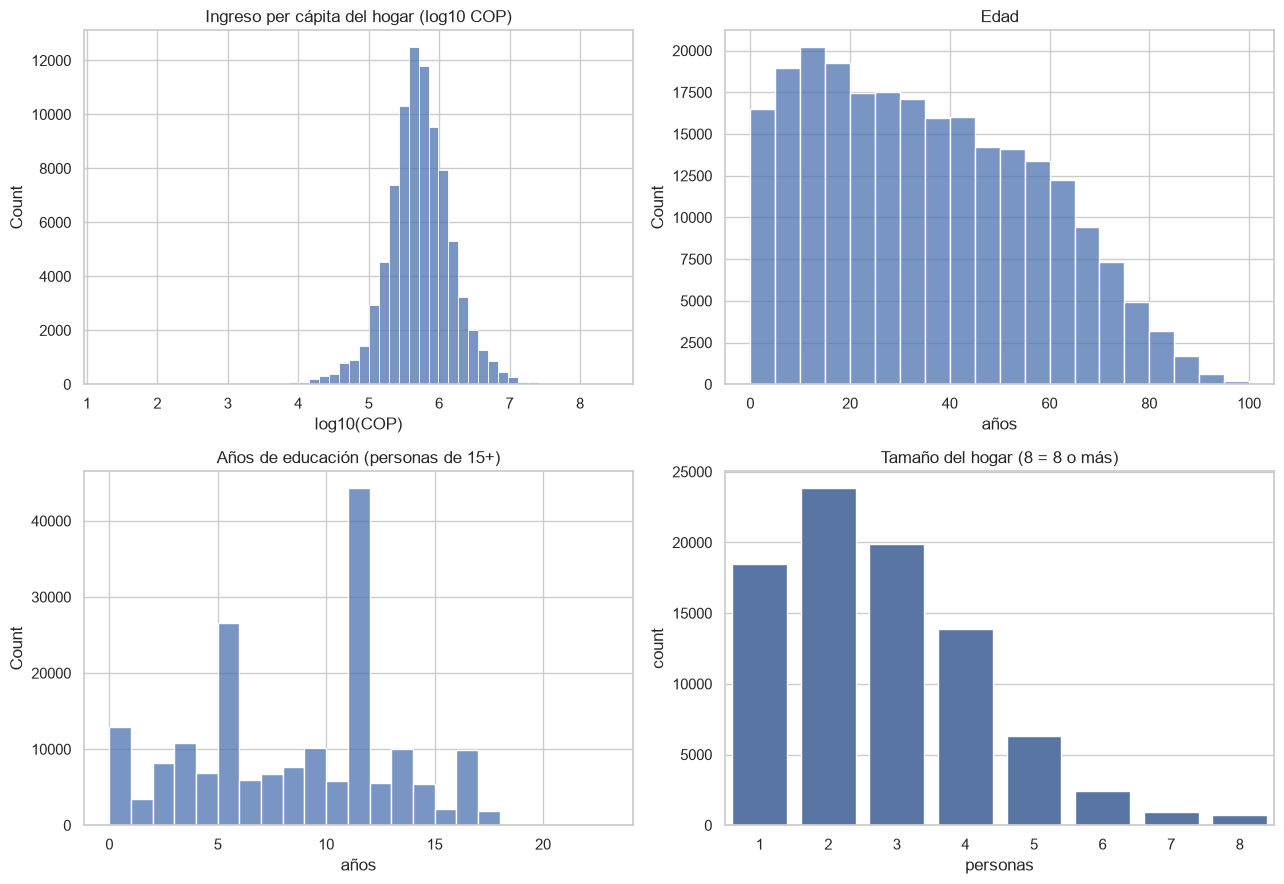

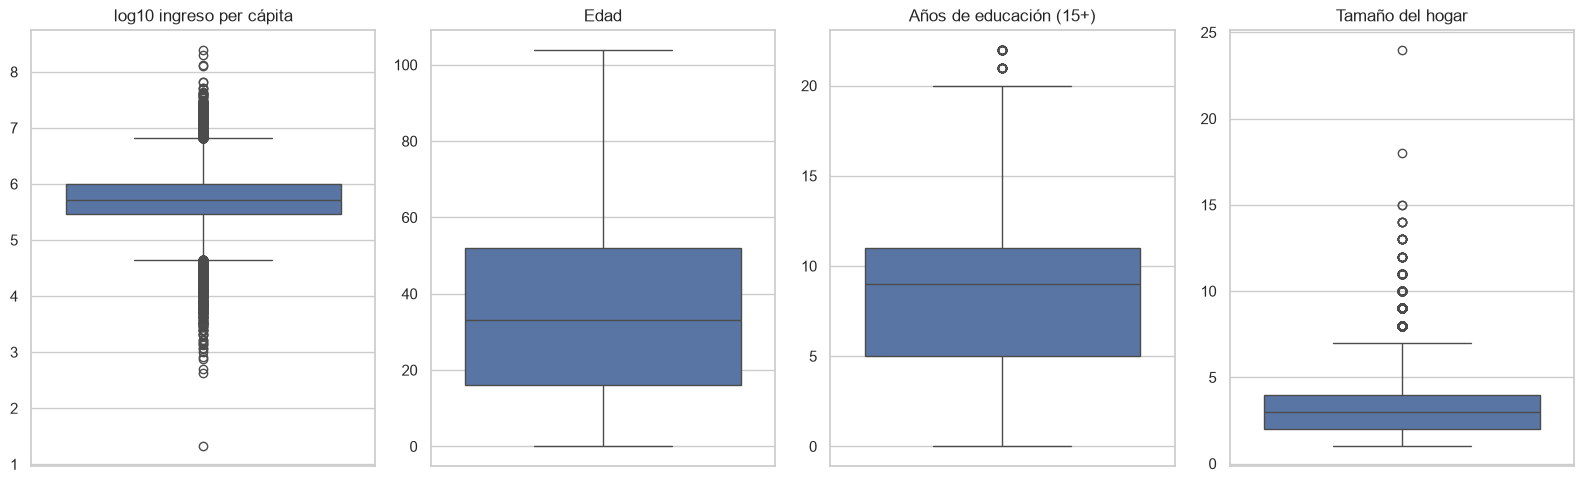

In [16]:
# 5.1 HISTOGRAMAS Y 5.2 BOXPLOTS
# Qué hace: grafica la distribución de las cuatro variables (histogramas) y sus valores atípicos (boxplots).
# Guarda las figuras en figures/ para usarlas en el informe.
fig, ax = plt.subplots(2, 2, figsize=(13, 9))
sns.histplot(np.log10(ing), bins=50, ax=ax[0, 0]); ax[0, 0].set(title="Ingreso per cápita del hogar (log10 COP)", xlabel="log10(COP)")
sns.histplot(per["P6040"], bins=range(0, 105, 5), ax=ax[0, 1]); ax[0, 1].set(title="Edad", xlabel="años")
sns.histplot(educ.clip(upper=22), bins=range(0, 24), ax=ax[1, 0]); ax[1, 0].set(title="Años de educación (personas de 15+)", xlabel="años")
sns.countplot(x=hog["TAM_HOGAR"].clip(upper=8), ax=ax[1, 1]); ax[1, 1].set(title="Tamaño del hogar (8 = 8 o más)", xlabel="personas")
plt.tight_layout(); plt.savefig(os.path.join(FIGURES, "05_histogramas.png"), dpi=150); plt.show()

# 5.2 Boxplots
fig, ax = plt.subplots(1, 4, figsize=(16, 5))
sns.boxplot(y=np.log10(ing), ax=ax[0]); ax[0].set(title="log10 ingreso per cápita", ylabel="")
sns.boxplot(y=per["P6040"], ax=ax[1]); ax[1].set(title="Edad", ylabel="")
sns.boxplot(y=educ, ax=ax[2]); ax[2].set(title="Años de educación (15+)", ylabel="")
sns.boxplot(y=hog["TAM_HOGAR"], ax=ax[3]); ax[3].set(title="Tamaño del hogar", ylabel="")
plt.tight_layout(); plt.savefig(os.path.join(FIGURES, "05_boxplots.png"), dpi=150); plt.show()

### Conclusiones del análisis univariado
*Estadísticas de la muestra, sin factor de expansión. Las cifras provienen de la tabla `tabla_uni`; verificarlas al volver a ejecutar.*

**Ingreso per cápita del hogar** (n = 84.768; se excluyó el 1,9% de hogares con ingreso 0). La media (≈ \$940.000) es cerca de 1,8 veces la mediana (≈ \$518.000), con desviación estándar de ≈ \$2,06 millones, asimetría de ≈ 42 y curtosis de ≈ 4.000: distribución extremadamente sesgada a la derecha, con valores extremos de hasta \$250 millones. El IQR es de \$712.500 (Q1 \$287.500; Q3 \$1.000.000). El 8,4% de los hogares supera el límite de atípicos de la regla 1,5·IQR (Q3 + 1,5·IQR ≈ \$2,07 millones). En escala log10 la distribución es casi simétrica (media 5,72; mediana 5,71; asimetría -0,17), lo que justifica usar el logaritmo en gráficos y modelos. El boxplot muestra además una cola baja de ingresos muy pequeños (mínimo de ≈ \$21 por persona), que se conserva y se declara como limitación.

**Edad** (n = 240.212). Media 34,7 y mediana 33 años, con rango de 0 a 104. IQR de 36 años (Q1 16; Q3 52), asimetría de 0,35 y curtosis de -0,83. Es una población joven: la mayor concentración está entre los 0 y 20 años, con cola decreciente hacia edades avanzadas.

**Años de educación, personas de 15 años o más** (n = 184.563; recortado en 22 años). Media ≈ 8,1 y mediana 9 años (básica secundaria). El 25% tiene 5 años o menos y el 75% tiene 11 años o menos. Distribución casi simétrica y aplanada, con picos en 5 y 11 años, que corresponden a primaria y bachillerato completos.

**Tamaño del hogar** (n = 86.405). Media 2,78 y mediana 3 personas, con moda en 2. IQR de 2 (Q1 2; Q3 4), asimetría de 1,10 y curtosis de 2,51: la mayoría de los hogares tiene entre 2 y 4 personas y los hogares grandes son una minoría (máximo 24).

## Estado y pendientes
**Listo:** secciones 0 a 8. Bases limpias en `data/processed/` (hogares y personas, en parquet) y figuras en `figures/`.

**IPM:** reconstrucción propia validada contra el DANE 2023. Incidencia de **personas**: 11,7% (oficial 12,1%); intensidad 40,2% (oficial 40,1%). A nivel de **hogares** la incidencia es 9,54%.

**Limitaciones:** ver la Sección 8.

**Pendiente:** modelo de regresión logística y pruebas de hipótesis (ver *Siguientes pasos*, Sección 8).

## 6. ANÁLISIS MULTIVARIADO

In [17]:
# CARGA DE LAS BASES LIMPIAS (Sección 6)
# Qué hace: carga los parquet generados en 4.2 para trabajar sin repetir la limpieza.
# Nota: PESOS se repite aquí (iguales a los de la Sección 4) para poder ejecutar la Sección 6 de forma independiente.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Rutas: raíz del repo y carpetas de datos procesados y figuras.
BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), ".."))
PROCESSED = os.path.join(BASE_PATH, "data", "processed")
FIGURES   = os.path.join(BASE_PATH, "figures")
sns.set_theme(style="whitegrid", context="notebook")

# hog: una fila por hogar (indicadores I01-I15, SCORE_IPM, POBRE_IPM, FEX_C...). per: una fila por persona.
hog = pd.read_parquet(os.path.join(PROCESSED, "ecv2023_hogares_limpia.parquet"))
per = pd.read_parquet(os.path.join(PROCESSED, "ecv2023_personas_limpia.parquet"))
# Pesos oficiales de los indicadores (los mismos de la Sección 4).
PESOS = {"I01_logro_educ": .10, "I02_analfabetismo": .10,
         "I03_inasistencia": .05, "I04_rezago": .05, "I05_primera_infancia": .05, "I06_trabajo_infantil": .05,
         "I07_desempleo_larga": .10, "I08_informal": .10,
         "I09_sin_aseguramiento": .10, "I10_barreras_salud": .10,
         "I11_agua": .04, "I12_excretas": .04, "I13_pisos": .04, "I14_paredes": .04, "I15_hacinamiento": .04}

print(hog.shape, per.shape)
hog.head()

(86405, 29) (240212, 14)


,DIRECTORIO,SECUENCIA_P,FEX_C,CLASE,REGION,P1_DEPARTAMENTO,TAM_HOGAR,I_HOGAR,PERCAPITA,ESTRATO,SEXO_JEFE,EDAD_JEFE,I01_logro_educ,I02_analfabetismo,I03_inasistencia,I04_rezago,I05_primera_infancia,I06_trabajo_infantil,I07_desempleo_larga,I08_informal,I09_sin_aseguramiento,I10_barreras_salud,I11_agua,I12_excretas,I13_pisos,I14_paredes,I15_hacinamiento,SCORE_IPM,POBRE_IPM
0,7910114,1,282.37,1,3,73,2,"775,000.00","387,500.00",2.00,2,43,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0.10,0
1,7910115,1,3.05,2,9,97,5,"2,200,000.00","440,000.00",1.00,1,54,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0.29,0
2,7910119,1,31.29,2,3,66,2,"410,000.00","205,000.00",1.00,2,57,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0.30,0
3,7910120,1,73.58,2,1,47,2,"720,000.00","360,000.00",1.00,2,65,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0.20,0
4,7910121,1,48.55,1,3,18,2,"1,892,500.00","946,250.00",1.00,2,45,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0


### 6.1 Correlaciones con el puntaje de pobreza

,SCORE_IPM,LOG_PERCAPITA,TAM_HOGAR,EDAD_JEFE
SCORE_IPM,1.00,-0.51,0.15,0.17
LOG_PERCAPITA,-0.51,1.00,-0.28,0.05
TAM_HOGAR,0.15,-0.28,1.00,-0.14
EDAD_JEFE,0.17,0.05,-0.14,1.00


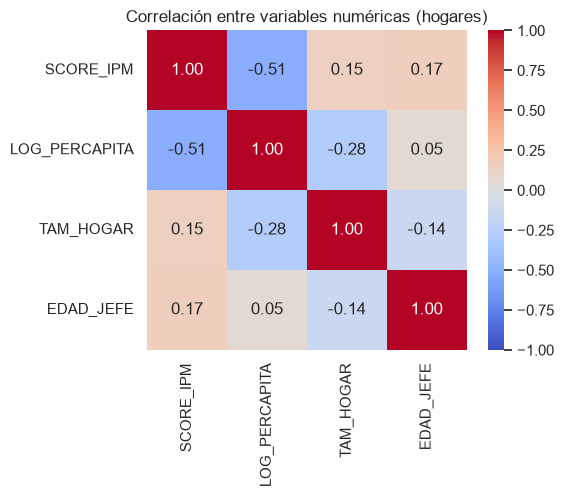

In [18]:
# 6.1 CORRELACIONES
# Qué hace: mide la correlación de Pearson entre el puntaje de pobreza (SCORE_IPM) y tres variables numéricas del hogar:
# ingreso per cápita (log10), tamaño del hogar y edad del jefe.
# Resultado: la correlación más fuerte es con el ingreso (-0,51); tamaño del hogar y edad del jefe se relacionan débilmente (0,15 y 0,17).
NUM_VARS = ["SCORE_IPM", "PERCAPITA", "TAM_HOGAR", "EDAD_JEFE"]

# Igual que en el univariado, el ingreso per cápita se ve mejor en log10
hog["LOG_PERCAPITA"] = np.where(hog["PERCAPITA"] > 0, np.log10(hog["PERCAPITA"]), np.nan)
NUM_VARS_LOG = ["SCORE_IPM", "LOG_PERCAPITA", "TAM_HOGAR", "EDAD_JEFE"]

# Matriz de correlaciones y su mapa de calor.
corr = hog[NUM_VARS_LOG].corr(method="pearson")
display(corr.round(3))

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlación entre variables numéricas (hogares)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, "06_heatmap_correlaciones.png"), dpi=150)
plt.show()

### 6.2 Privación por indicador (% de hogares)

,indicador,pct_privacion_ponderado
7,I08_informal,69.68
0,I01_logro_educ,39.78
3,I04_rezago,24.29
6,I07_desempleo_larga,13.32
11,I12_excretas,9.55
10,I11_agua,9.33
1,I02_analfabetismo,7.61
14,I15_hacinamiento,7.13
8,I09_sin_aseguramiento,6.79
12,I13_pisos,5.36


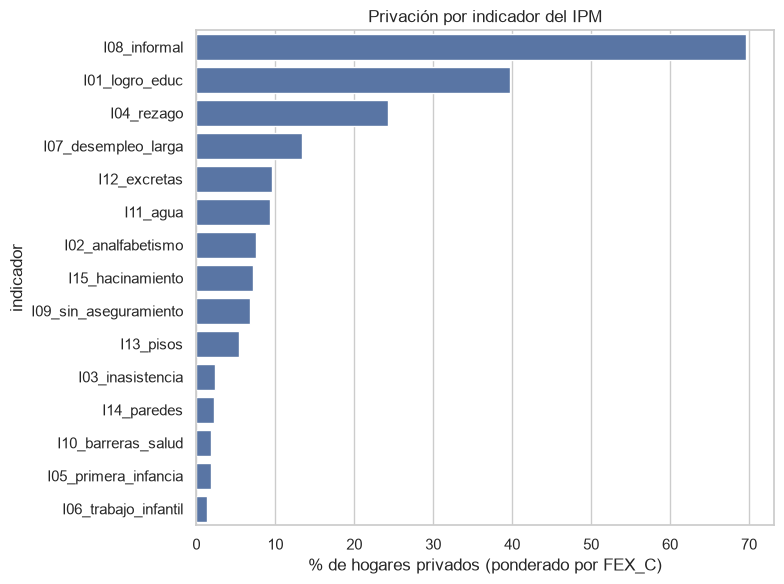

In [19]:
# 6.2 PRIVACIÓN POR INDICADOR
# Qué hace: calcula el % de hogares privados en cada uno de los 15 indicadores, ponderado con FEX_C (representa a toda la población).
# Resultado: la informalidad (I08) es la privación más frecuente (69,7%), seguida del bajo logro educativo (39,8%).
# Lista de los 15 indicadores.
indicadores = ["I01_logro_educ", "I02_analfabetismo", "I03_inasistencia", "I04_rezago",
               "I05_primera_infancia", "I06_trabajo_infantil", "I07_desempleo_larga",
               "I08_informal", "I09_sin_aseguramiento", "I10_barreras_salud",
               "I11_agua", "I12_excretas", "I13_pisos", "I14_paredes", "I15_hacinamiento"]

# Tasa ponderada = suma(privación x FEX_C) / suma(FEX_C) x 100.
def tasa_privacion_ponderada(df, col, peso="FEX_C"):
    return (df[col] * df[peso]).sum() / df[peso].sum() * 100

resumen_indicadores = pd.DataFrame({
    "indicador": indicadores,
    "pct_privacion_ponderado": [tasa_privacion_ponderada(hog, i) for i in indicadores]
}).sort_values("pct_privacion_ponderado", ascending=False)

display(resumen_indicadores)

plt.figure(figsize=(8, 6))
sns.barplot(data=resumen_indicadores, y="indicador", x="pct_privacion_ponderado", color="#4C72B0")
plt.xlabel("% de hogares privados (ponderado por FEX_C)")
plt.title("Privación por indicador del IPM")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, "06_barras_indicadores_ipm.png"), dpi=150)
plt.show()

### 6.3 Incidencia por zona, región, sexo del jefe y estrato (% de hogares)


--- Incidencia de pobreza multidimensional por CLASE ---


,CLASE,incidencia_pct
0,1,5.79
1,2,22.42


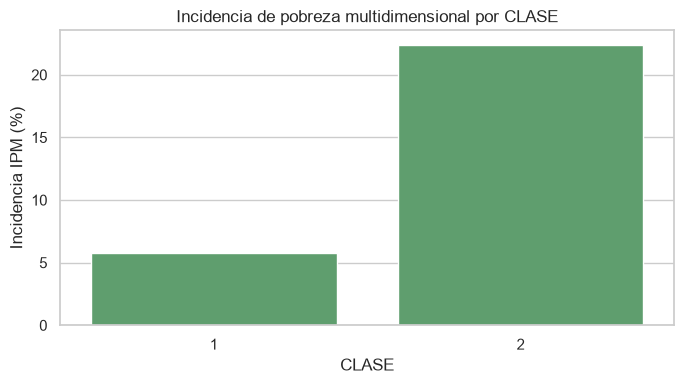


--- Incidencia de pobreza multidimensional por REGION ---


,REGION,incidencia_pct
0,1,16.99
1,2,8.18
2,3,8.73
3,4,16.91
4,5,2.38
5,6,6.69
6,7,4.59
7,8,4.97
8,9,20.17


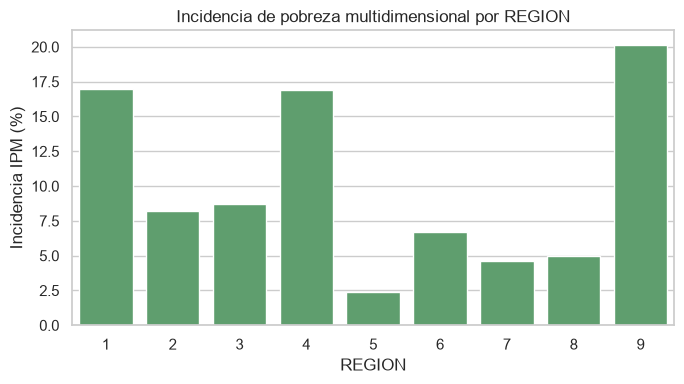


--- Incidencia de pobreza multidimensional por SEXO_JEFE ---


,SEXO_JEFE,incidencia_pct
0,1,8.99
1,2,10.20


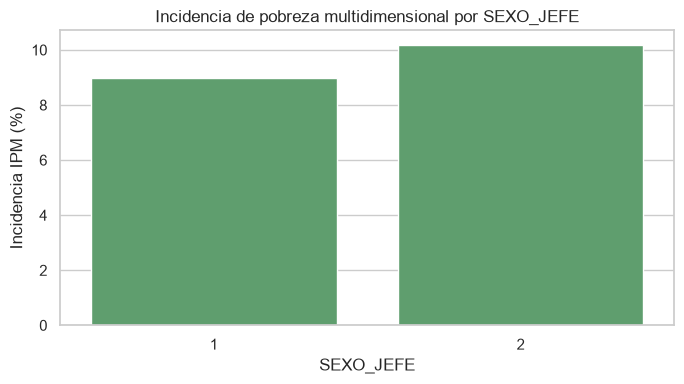


--- Incidencia de pobreza multidimensional por ESTRATO ---


,ESTRATO,incidencia_pct
0,1.00,15.23
1,2.00,5.69
2,3.00,1.83
3,4.00,0.45
4,5.00,0.38
5,6.00,0.15


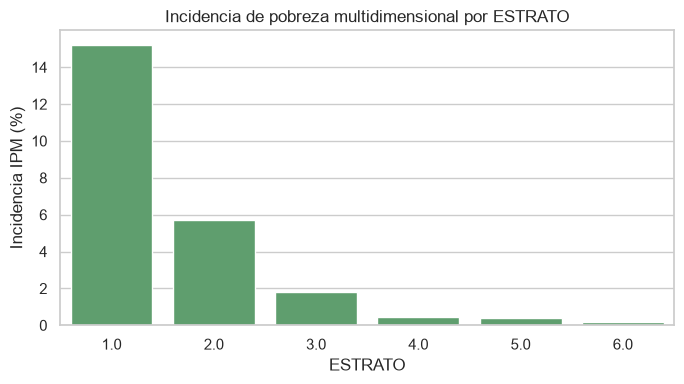

In [20]:
# 6.3 INCIDENCIA DE POBREZA POR GRUPOS (% de hogares)
# Qué hace: calcula el % de hogares pobres (POBRE_IPM = 1), ponderado con FEX_C, por zona (CLASE), región, sexo del jefe y estrato, y grafica cada comparación.
# Resultado: la incidencia varía mucho por zona (rural 22,4% vs urbano 5,8%) y región, y poco por sexo del jefe (10,2% vs 9,0%).
def incidencia_ponderada(df, grupo, peso="FEX_C", pobre="POBRE_IPM"):
    out = df.groupby(grupo).apply(
        lambda g: (g[pobre] * g[peso]).sum() / g[peso].sum() * 100
    ).reset_index(name="incidencia_pct")
    return out

# Repite el cálculo y el gráfico para cada variable de agrupación.
for grupo in ["CLASE", "REGION", "SEXO_JEFE", "ESTRATO"]:
    tabla = incidencia_ponderada(hog, grupo)
    print(f"\n--- Incidencia de pobreza multidimensional por {grupo} ---")
    display(tabla)

    plt.figure(figsize=(7, 4))
    sns.barplot(data=tabla, x=grupo, y="incidencia_pct", color="#55A868")
    plt.ylabel("Incidencia IPM (%)")
    plt.title(f"Incidencia de pobreza multidimensional por {grupo}")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES, f"06_barras_incidencia_{grupo.lower()}.png"), dpi=150)
    plt.show()

REGION (agrupación de departamentos según la ficha técnica de la ECV, V16, p. 38):
1=Caribe, 2=Oriental, 3=Central, 4=Pacífica (Cauca, Chocó y Nariño, sin Valle), 5=Bogotá (cabecera), 6=Antioquia, 7=Valle del Cauca, 8=San Andrés, 9=Orinoquía-Amazonía

SEXO_JEFE:
1=Hombre, 2=Mujer

CLASE:
1=Urbano (cabecera municipal), 2=Rural (centros poblados y rural disperso)


In [21]:
# 6.3b VERIFICACIÓN DEL MAPEO DE REGION
# Qué hace: compara el código REGION de cada departamento con la agrupación oficial de la ficha técnica de la ECV (V16, p. 38).
# Resultado: solo Bogotá (11) aparece en dos regiones (2 y 5), porque su zona rural pertenece a la región Oriental.
ESPERADA = {1: [8, 13, 20, 23, 44, 47, 70],         # Caribe
            2: [15, 25, 50, 54, 68],                 # Oriental
            3: [17, 18, 41, 63, 66, 73],             # Central
            4: [19, 27, 52],                         # Pacífica (sin Valle)
            5: [11], 6: [5], 7: [76], 8: [88],       # Bogotá, Antioquia, Valle, San Andrés
            9: [81, 85, 86, 91, 94, 95, 97, 99]}     # Orinoquía-Amazonía
esp = {d: r for r, ds in ESPERADA.items() for d in ds}
reg_datos = hog.groupby("P1_DEPARTAMENTO")["REGION"].agg(lambda s: sorted(s.unique()))
chk = pd.DataFrame({"en_datos": reg_datos, "esperada": pd.Series(esp)})
chk["coincide"] = [d == [e] for d, e in zip(chk["en_datos"], chk["esperada"])]
display(chk[~chk["coincide"]])    # vacío = todo coincide (Bogotá aparece por su zona rural)

,en_datos,esperada,coincide
11,"[2, 5]",5,False


**Conclusión.** Los 32 departamentos coinciden con la agrupación de la ficha técnica V16 (p. 38). La única excepción es Bogotá, cuya zona rural pertenece a la región Oriental; por eso la región 5 corresponde a Bogotá (cabecera).

### 6.4 Incidencia a nivel de personas

In [22]:
# 6.4 INCIDENCIA A NIVEL DE PERSONAS
# Qué hace: asigna a cada persona el estado de pobreza de su hogar y calcula la incidencia ponderada con el FEX_C de personas.
# Por qué: el DANE publica la incidencia como % de personas; esta es la cifra comparable con el 12,1% oficial (aquí 11,66%).
personas_pobreza = per.merge(
    hog[["DIRECTORIO", "SECUENCIA_P", "POBRE_IPM", "CLASE"]],
    on=["DIRECTORIO", "SECUENCIA_P"], how="left"
)

incidencia_personas = (personas_pobreza["POBRE_IPM"] * personas_pobreza["FEX_C"]).sum() \
                       / personas_pobreza["FEX_C"].sum() * 100
print(f"Incidencia de pobreza multidimensional (personas, nacional): {incidencia_personas:.2f}%")

# Por CLASE, a nivel persona (para comparar con la validación de la Sección 4.1: 7,6% / 24,8%)
inc_persona_clase = personas_pobreza.groupby("CLASE").apply(
    lambda g: (g["POBRE_IPM"] * g["FEX_C"]).sum() / g["FEX_C"].sum() * 100
).reset_index(name="incidencia_pct")
display(inc_persona_clase)

Incidencia de pobreza multidimensional (personas, nacional): 11.66%


,CLASE,incidencia_pct
0,1,7.60
1,2,24.85


### 6.5 Contribución por dimensión y comparación entre pobres y no pobres

,pct_contribucion_pobres
Educación,37.40
Trabajo,32.40
Vivienda y servicios,13.10
Niñez y juventud,9.70
Salud,7.40


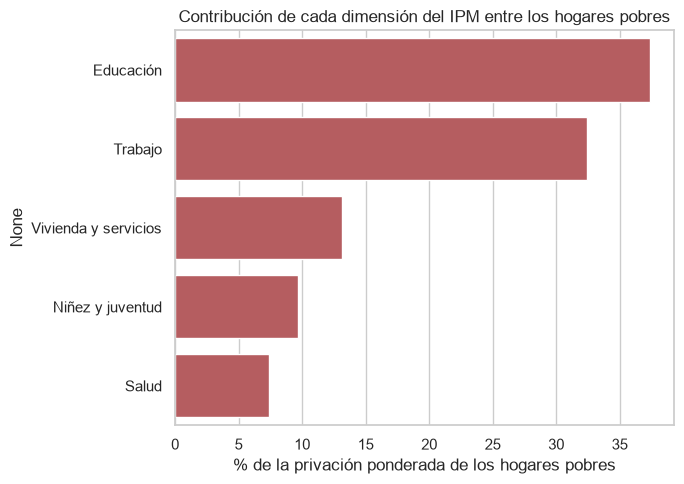

,pobres_%,no_pobres_%,razon
I02_analfabetismo,53.30,2.80,19.10
I03_inasistencia,13.70,1.10,12.00
I06_trabajo_infantil,6.90,0.70,10.10
I13_pisos,27.90,3.00,9.30
I05_primera_infancia,8.40,1.10,7.50
I14_paredes,10.00,1.40,7.20
I11_agua,36.30,6.50,5.60
I12_excretas,36.20,6.70,5.40
I10_barreras_salud,7.00,1.30,5.30
I09_sin_aseguramiento,22.50,5.10,4.40


Incidencia nacional, hogares: 9.54 %


In [23]:
# 6.5 CONTRIBUCIÓN DE LAS DIMENSIONES ENTRE LOS HOGARES POBRES
# Qué hace: (1) agrupa los 15 indicadores en las 5 dimensiones y calcula cuánto aporta cada una a la privación ponderada de los hogares pobres (así lo mide el DANE);
# (2) compara el % de privación de pobres vs no pobres en cada indicador (razón = pobres / no pobres).
# Resultado: educación (37,4%) y trabajo (32,4%) aportan casi 70%; el analfabetismo separa mucho más a pobres de no pobres que la informalidad.
# Ojo: POBRE_IPM se construye con estos mismos indicadores, así que parte de la diferencia es mecánica.
DIMENSIONES = {
    "Educación": ["I01_logro_educ", "I02_analfabetismo"],
    "Niñez y juventud": ["I03_inasistencia", "I04_rezago", "I05_primera_infancia", "I06_trabajo_infantil"],
    "Trabajo": ["I07_desempleo_larga", "I08_informal"],
    "Salud": ["I09_sin_aseguramiento", "I10_barreras_salud"],
    "Vivienda y servicios": ["I11_agua", "I12_excretas", "I13_pisos", "I14_paredes", "I15_hacinamiento"],
}
# Hogares pobres y no pobres.
pob = hog[hog["POBRE_IPM"] == 1]
no  = hog[hog["POBRE_IPM"] == 0]

# Aporte de cada indicador = % de pobres privados x peso del indicador; luego se suma por dimensión y se expresa como % del total.
aporte = pd.Series({c: np.average(pob[c], weights=pob["FEX_C"]) * PESOS[c] for c in indicadores})
contrib = pd.Series({d: aporte[cols].sum() for d, cols in DIMENSIONES.items()})
resumen_dim = (contrib / aporte.sum() * 100).round(1).sort_values(ascending=False).rename("pct_contribucion_pobres").to_frame()
display(resumen_dim)

plt.figure(figsize=(7, 5))
sns.barplot(x=resumen_dim["pct_contribucion_pobres"], y=resumen_dim.index, color="#C44E52")
plt.xlabel("% de la privación ponderada de los hogares pobres")
plt.title("Contribución de cada dimensión del IPM entre los hogares pobres")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, "06_barras_dimensiones_ipm.png"), dpi=150)
plt.show()

# ¿Qué indicadores distinguen a los pobres de los no pobres?
cmp = pd.DataFrame({
    "pobres_%":    [100 * np.average(pob[c], weights=pob["FEX_C"]) for c in indicadores],
    "no_pobres_%": [100 * np.average(no[c],  weights=no["FEX_C"])  for c in indicadores]},
    index=indicadores)
cmp["razon"] = cmp["pobres_%"] / cmp["no_pobres_%"]
display(cmp.round(1).sort_values("razon", ascending=False))

# Incidencia nacional a nivel de HOGARES (distinta de la de personas, 11,66%).
print("Incidencia nacional, hogares:", round(100 * np.average(hog["POBRE_IPM"], weights=hog["FEX_C"]), 2), "%")

### Conclusiones del análisis multivariado

**Relación entre ingreso y pobreza.** Las variables numéricas muestran que el ingreso por persona del hogar es la que más se relaciona con la pobreza multidimensional: entre más alto el ingreso, más bajo el puntaje de pobreza (correlación de -0,51). El tamaño del hogar (0,15) y la edad del jefe de hogar (0,17) se relacionan débilmente con el puntaje de pobreza.

**El trabajo informal es la privación más común.** De los 15 indicadores que componen el índice, el trabajo informal es, por mucho, el más frecuente: casi 7 de cada 10 hogares (69,7%) están en esta situación (el indicador incluye también a los hogares sin ocupados que no son pensionados). Le sigue el bajo nivel educativo (39,8%). El resto de indicadores afecta a menos del 25% de los hogares.

**Grandes diferencias entre zonas.** La incidencia de pobreza multidimensional (% de hogares) es casi 4 veces más alta en zonas rurales (22,4%) que en zonas urbanas (5,8%), y varía muchísimo según la región: Bogotá (cabecera) tiene la incidencia más baja (2,4%), mientras que Orinoquía-Amazonía, el Caribe y la región Pacífica superan el 16%. El estrato socioeconómico muestra el mismo patrón: a menor estrato, mayor pobreza, bajando de 15,2% en estrato 1 a casi 0% en estrato 6.

**Diferencias por sexo del jefe de hogar.** Los hogares con jefatura de mujeres tienen una incidencia un poco más alta (10,2%) que los de jefatura de hombres (9,0%), aunque la diferencia es menor que la de zona o región.

**Qué pesa más entre los hogares pobres.** Al agrupar los 15 indicadores en las 5 dimensiones y calcular su aporte entre los hogares pobres, educación (37,4%) y trabajo (32,4%) concentran casi 70% de la privación ponderada; vivienda (13,1%), niñez (9,7%) y salud (7,4%) aportan el resto. La informalidad, aunque muy común (69,7%), distingue poco entre pobres (99,1%) y no pobres (66,6%), mientras que el analfabetismo (53,3% frente a 2,8%) los separa mucho más. Estas comparaciones son descriptivas: POBRE_IPM se construye con los mismos indicadores, así que parte de la diferencia es mecánica.

## 7. HALLAZGOS

### Hallazgo 1 — Educación y trabajo concentran la privación de los hogares pobres

Entre los hogares pobres, educación (37,4%) y trabajo (32,4%) concentran casi 70% de la privación ponderada; vivienda aporta 13,1%, niñez 9,7% y salud 7,4%. Casi todos los hogares pobres tienen bajo logro educativo (95,7%) e informalidad (99,1%).

**¿Por qué es relevante?** Muestra dónde se concentran las carencias de los hogares pobres: casi siete de cada diez puntos de privación vienen de educación y trabajo, y los dos primeros lugares coinciden con el DANE (35,9% y 30% en 2024). Apunta a que el análisis y las políticas contra la pobreza multidimensional deberían priorizar el capital educativo y la calidad del empleo, más allá de vivienda y salud. Es una descripción de asociación: no demuestra que mejorar esas dimensiones reduzca la pobreza.

### Hallazgo 2 — La incidencia varía mucho por zona y región, y poco por el sexo del jefe

La incidencia es 22,4% en hogares rurales frente a 5,8% en urbanos, y va de 2,4% en Bogotá (cabecera) a 20,2% en Orinoquía-Amazonía. Según el sexo del jefe la brecha es de solo 1,2 puntos (10,2% mujeres, 9,0% hombres).

**¿Por qué es relevante?** Confirma una fuerte dimensión territorial de la pobreza: los hogares rurales y las regiones de Orinoquía-Amazonía, Caribe y Pacífica concentran las mayores incidencias, mientras que el sexo del jefe marca una diferencia pequeña. Esto respalda diseñar estrategias diferenciadas por zona y región. La comparación es descriptiva y no controla otros factores, como ingreso, educación o estrato, que se evaluarán en el modelo.

### Hallazgo 3 — La informalidad es la privación más frecuente, pero distingue poco

La informalidad es la privación más frecuente (69,7% de los hogares), pero distingue poco: afecta al 99,1% de los pobres y al 66,6% de los no pobres. Analfabetismo separa más: 53,3% frente a 2,8%, 19 veces.

**¿Por qué es relevante?** Una privación frecuente no necesariamente identifica la pobreza: dos de cada tres hogares no pobres también presentan informalidad. Indicadores menos comunes, como analfabetismo, inasistencia escolar (13,7% frente a 1,1%) o pisos de tierra (27,9% frente a 3,0%), separan mucho mejor a los hogares pobres. Parte de esa diferencia es mecánica, porque POBRE_IPM se construye con esos indicadores. Por eso el modelo de la siguiente etapa usará variables externas al índice, no los indicadores.

## 8. CONCLUSIONES Y SIGUIENTES PASOS

### Conclusión general

El análisis descriptivo y multivariado de la ECV 2023 muestra que, entre los hogares pobres, la privación se concentra en educación (37,4%) y trabajo (32,4%), y que la incidencia varía mucho más por zona y región que por el sexo del jefe de hogar. La incidencia reconstruida es 9,54% de los hogares y 11,66% de las personas; esta última queda cerca de la cifra oficial del DANE (12,1%, publicada como % de personas), lo que respalda la calidad de la reconstrucción del índice.

### Limitaciones conocidas

- El indicador de bajo logro educativo (I01) sale más alto de lo esperado (≈40%), posiblemente por decisiones propias en la reconstrucción del IPM (ver sección 4.1).
- El indicador de primera infancia (I05) no incluye el componente de alimentación en el jardín, por no estar disponible en los microdatos.
- 11.019 hogares quedaron sin estrato válido y no entran en esa comparación.
- El análisis univariado (sección 5) no usó el factor de expansión; el multivariado (sección 6) sí lo usa en todas las comparaciones.
- Los resultados de "incidencia por hogar" e "incidencia por persona" no son el mismo número (por ejemplo, zona rural: 22,4% vs. 24,9%) porque los hogares pobres tienden a ser más grandes; ambos son correctos, pero miden cosas distintas.
- Las diferencias entre hogares pobres y no pobres son en parte mecánicas, porque POBRE_IPM se construye con los mismos indicadores.

### Siguientes pasos

1. **Modelo de regresión logística para `POBRE_IPM`.** Como el IPM se calcula con los 15 indicadores, usarlos como variables explicativas sería circular (el modelo acertaría por construcción). El modelo debe usar variables externas al índice: ingreso per cápita (log10), estrato, zona, región, sexo y edad del jefe, y tamaño del hogar.
2. **Pruebas de hipótesis** sobre las diferencias observadas: chi-cuadrado de `POBRE_IPM` frente a zona, región y sexo del jefe, y ANOVA (o Kruskal-Wallis) del ingreso entre grupos. Con una muestra compleja, la significancia debe considerar el diseño muestral (estrato y UPM de `diseno_muestra`) y no solo `FEX_C`.
3. **Mejorar la reconstrucción del IPM:** incluir el componente de alimentación en primera infancia y revisar el indicador de bajo logro educativo (≈ 40%, más alto de lo esperado).
4. **Evaluar el modelo** con una partición entrenamiento/prueba (AUC y matriz de confusión).